In [64]:
import importlib
import numpy as np
import pandas as pd

import load_data
import assign_labels
import build_features
import train
import plots
import extract_ontology
import build_topology_graph
import build_ontology

importlib.reload(load_data)
importlib.reload(assign_labels)
importlib.reload(build_features)
importlib.reload(train)
importlib.reload(plots)
importlib.reload(extract_ontology)
importlib.reload(build_topology_graph)
importlib.reload(build_ontology)

from load_data import load_alerts_from_json
from assign_labels import add_labels_to_df
from build_features import build_dyn_features, build_static_features
from train import train_and_evaluate
from plots import (
    plot_roc,
    plot_alert_reduction,
    plot_feature_importance,
    plot_confidence_distribution,
    plot_top_error_categories,
    plot_all
)
from extract_ontology import topology_edges, host_sets
from build_topology_graph import plot_scenario_topologies
from build_ontology import build_all_scenarios

### Alert JSONs to CSV

In [42]:
output_file = "combined_ait.csv"
dir_path = "../data/ait_ads"

df = load_alerts_from_json(output_file, dir_path)

Opening file ../data/ait_ads/harrison_aminer.json...
Opening file ../data/ait_ads/wardbeck_wazuh.json...
Opening file ../data/ait_ads/wheeler_wazuh.json...
Opening file ../data/ait_ads/shaw_wazuh.json...
Opening file ../data/ait_ads/wilson_aminer.json...
Opening file ../data/ait_ads/fox_aminer.json...
Opening file ../data/ait_ads/santos_wazuh.json...
Opening file ../data/ait_ads/fox_wazuh.json...
Opening file ../data/ait_ads/shaw_aminer.json...
Opening file ../data/ait_ads/wheeler_aminer.json...
Opening file ../data/ait_ads/russellmitchell_aminer.json...
Opening file ../data/ait_ads/harrison_wazuh.json...
Opening file ../data/ait_ads/wilson_wazuh.json...
Opening file ../data/ait_ads/santos_aminer.json...
Opening file ../data/ait_ads/russellmitchell_wazuh.json...
Opening file ../data/ait_ads/wardbeck_aminer.json...
Writing data to combined_ait.csv...
Done.


In [43]:
dataframe = pd.read_csv("../data/ait_ads/combined_ait.csv")
dataframe.head()
print(dataframe["timestamp"].min(), dataframe["timestamp"].max())
dataframe["timestamp"].map(type).value_counts()

/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_90808/2708033298.py:1: DtypeWarning: Columns (7,10,11,12,15,22,29,30) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframe = pd.read_csv("../data/ait_ads/combined_ait.csv")


2022-01-14 00:00:01.750000+00:00 2022-02-08 23:59:46.130000114+00:00


timestamp
<class 'str'>    2655821
Name: count, dtype: int64

In [46]:
dataframe.columns

Index(['timestamp', 'category', 'entity', 'raw_log', 'scenario', 'source',
       'host_ip', 'host', 'rule_id', 'rule_desc', 'groups', 'srcip', 'dstip',
       'srcport', 'dstport', 'proto', 'is_auth_event', 'is_cred_event',
       'is_web_event', 'is_cron', 'is_success', 'is_uid0',
       'aminer_component_type', 'aminer_training_mode', 'aminer_new_event',
       'wazuh_level', 'wazuh_antivirus', 'wazuh_update', 'is_ids_alert',
       'ids_signature', 'ids_category', 'ids_severity', 'exploit_class'],
      dtype='object')

In [47]:
dataframe["is_ids_alert"].value_counts(dropna=False).head()

is_ids_alert
0    2042463
1     613358
Name: count, dtype: int64

In [48]:
dataframe[dataframe["rule_desc"]=="IDS event."][["ids_signature","ids_category","ids_severity","proto","srcip","dstip","dstport","exploit_class"]].head(5)

,ids_signature,ids_category,ids_severity,proto,srcip,dstip,dstport,exploit_class
10204,ET POLICY GNU/Linux APT User-Agent Outbound li...,Not Suspicious Traffic,3.0,TCP,192.168.96.4,91.189.95.85,80.0,policy_indicator
10206,ET POLICY GNU/Linux APT User-Agent Outbound li...,Not Suspicious Traffic,3.0,TCP,192.168.96.4,91.189.88.152,80.0,policy_indicator
10207,ET POLICY GNU/Linux APT User-Agent Outbound li...,Not Suspicious Traffic,3.0,TCP,192.168.96.4,91.189.88.152,80.0,policy_indicator
10210,ET POLICY GNU/Linux APT User-Agent Outbound li...,Not Suspicious Traffic,3.0,TCP,192.168.96.4,91.189.88.152,80.0,policy_indicator
10211,ET POLICY GNU/Linux APT User-Agent Outbound li...,Not Suspicious Traffic,3.0,TCP,192.168.96.4,91.189.91.39,80.0,policy_indicator


In [50]:
dataframe["exploit_class"].value_counts().head(20)

exploit_class
unknown             1913052
tls_fingerprint      420465
dns_suspicious       184831
rce                  121828
malware                8407
policy_indicator       7120
bruteforce_auth          90
ids_policy_info          24
recon_scan                4
Name: count, dtype: int64

In [51]:
dataframe[dataframe["ids_signature"].notna()]["exploit_class"].value_counts().head(20)


exploit_class
tls_fingerprint     420465
dns_suspicious      184831
policy_indicator      7120
unknown                914
ids_policy_info         24
recon_scan               4
Name: count, dtype: int64

In [52]:
dataframe[dataframe["scenario"] == "shaw"]["exploit_class"].value_counts()

exploit_class
unknown             35717
tls_fingerprint     32128
malware              1291
policy_indicator     1032
rce                   378
dns_suspicious        228
bruteforce_auth         4
recon_scan              4
Name: count, dtype: int64

In [53]:
dataframe[dataframe["scenario"] == "shaw"][["srcip","dstip"]].dropna().shape

(33634, 2)

In [54]:
dataframe["ids_category"].value_counts().sort_index()

ids_category
(null)                                  3
Attempted User Privilege Gain          24
Generic Protocol Command Decode    421175
Misc activity                           4
Not Suspicious Traffic               6844
Potentially Bad Traffic            185029
Web Application Attack                276
Name: count, dtype: int64

In [55]:
edge_table = topology_edges(dataframe, min_weight=3)
edge_table.head(10)

,scenario,srcip,dstip,proto,dstport,weight
0,fox,10.35.33.111,91.189.88.142,TCP,80.0,28
1,fox,10.35.33.111,91.189.88.152,TCP,80.0,16
2,fox,10.35.33.111,91.189.91.38,TCP,80.0,6
4,fox,10.35.33.111,91.189.95.85,TCP,80.0,10
5,fox,10.35.35.206,91.189.88.142,TCP,80.0,16
6,fox,10.35.35.206,91.189.88.152,TCP,80.0,24
8,fox,10.35.35.206,91.189.91.39,TCP,80.0,8
9,fox,10.35.35.206,91.189.95.85,TCP,80.0,10
10,fox,100.21.15.207,192.168.128.4,TCP,49634.0,4
11,fox,100.24.82.208,192.168.128.4,TCP,58058.0,4


In [56]:
host_summary = host_sets(dataframe, edge_table)
host_summary

/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/extract_ontology.py:92: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: set(g["srcip"]).union(set(g["dstip"])))


,scenario,n_active_hosts,n_hosts_in_edges,isolated_but_active
0,fox,13,889,6
1,harrison,11,951,3
2,russellmitchell,11,634,3
3,santos,11,1212,3
4,shaw,12,1094,10
5,wardbeck,12,1409,4
6,wheeler,13,1448,5
7,wilson,11,1461,3


In [65]:
scenarios = sorted(edge_table["scenario"].unique())

for sc in scenarios:
    plot_scenario_topologies(edge_table, sc, min_weight=10, remove_hubs_k=3, make_subnet_view=True, subnet_k=3)

In [66]:
build_all_scenarios("../out/ontology_inputs/scenario_hosts.csv",
                    "../out/ontology_inputs/scenario_services.csv",
                    "../out/ontology_inputs/scenario_edges.csv",
                    "../data/ait_ads/combined_ait.csv",
                    out_dir="../out/ontology_out",
                    k=3)

/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/build_ontology.py:156: DtypeWarning: Columns (7,10,11,12,15,22,29,30) have mixed types. Specify dtype option on import or set low_memory=False.
  alerts_df = pd.read_csv(alerts_csv)


Wrote ../out/ontology_out/ontology_fox.ttl
Wrote ../out/ontology_out/ontology_harrison.ttl
Wrote ../out/ontology_out/ontology_russellmitchell.ttl
Wrote ../out/ontology_out/ontology_santos.ttl
Wrote ../out/ontology_out/ontology_shaw.ttl
Wrote ../out/ontology_out/ontology_wardbeck.ttl
Wrote ../out/ontology_out/ontology_wheeler.ttl
Wrote ../out/ontology_out/ontology_wilson.ttl


### labelling

In [52]:
add_labels_to_df(dataframe)

KeyboardInterrupt: 

In [ ]:
df = pd.read_csv("../data/ait_ads/combined_ait_labeled.csv")


/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_49238/2579065682.py:1: DtypeWarning: Columns (7,10,11,12,15,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/ait_ads/combined_ait_labeled.csv")


## Training loop

/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_60853/1733606799.py:2: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/ait_ads/combined_ait_labeled.csv")


(623576, 23)
(623576,)


/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/

Fold 1 ROC-AUC: 0.531


/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Fold 2 ROC-AUC: 0.957


/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 3 ROC-AUC: 0.905
Mean ROC-AUC: 0.798


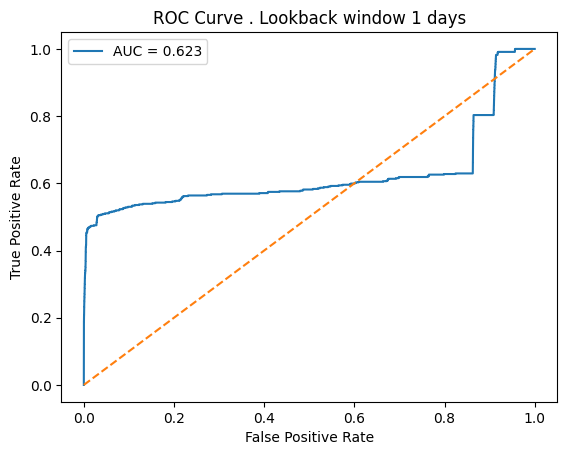

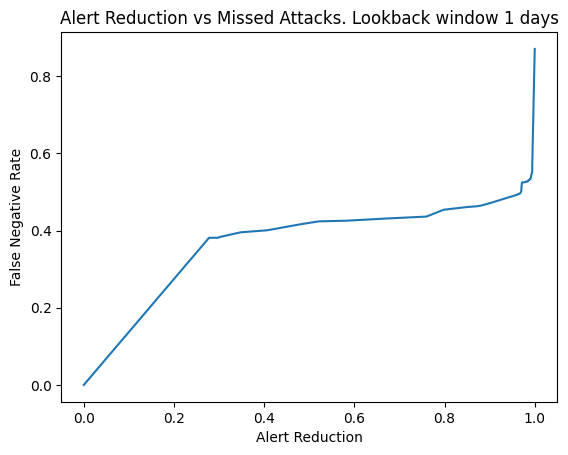

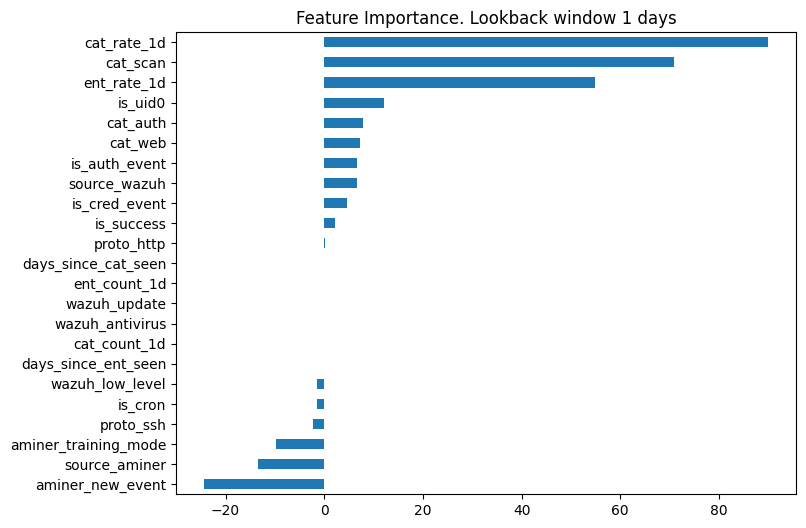

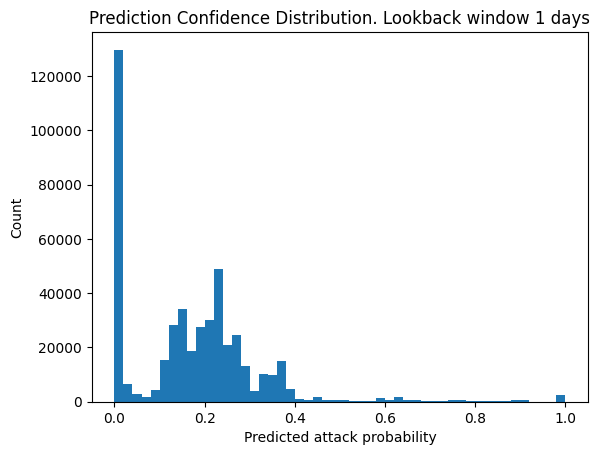

(623576, 23)
(623576,)


/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/

Fold 1 ROC-AUC: 0.507


/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Fold 2 ROC-AUC: 0.947


/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 3 ROC-AUC: 0.839
Mean ROC-AUC: 0.764


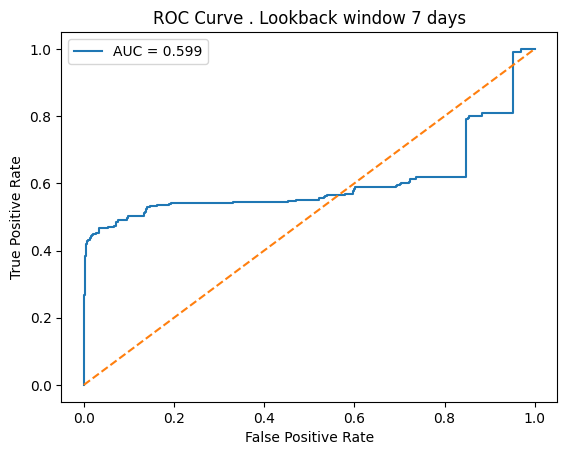

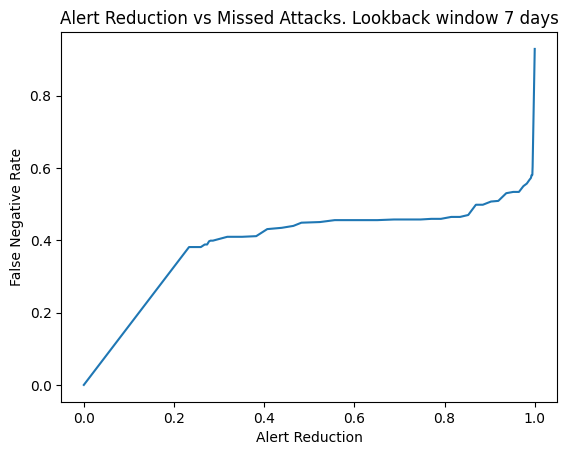

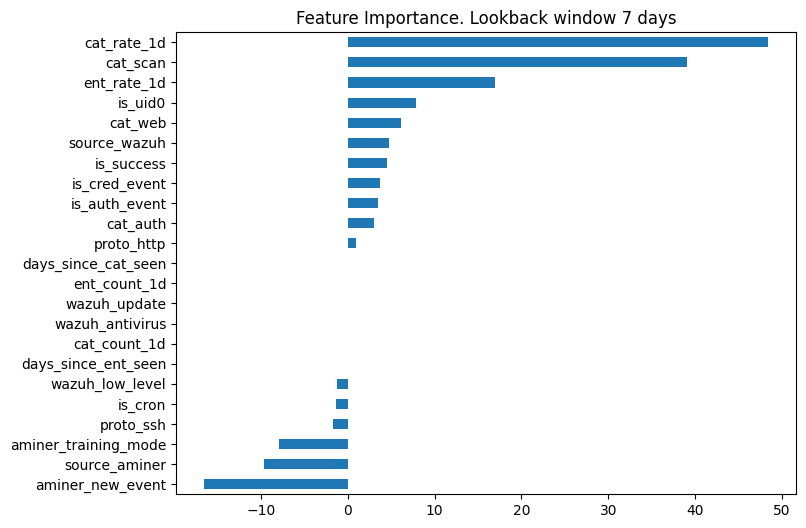

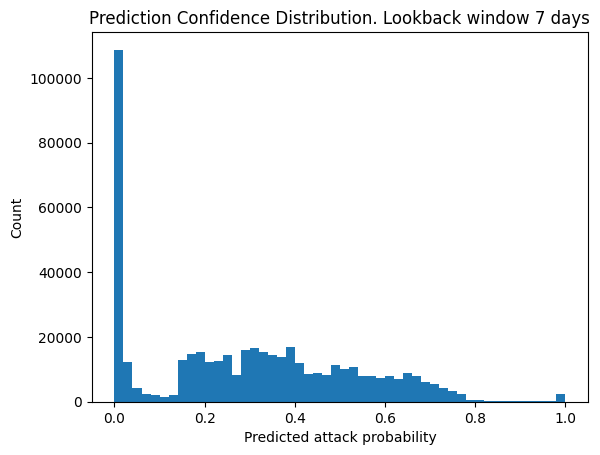

(623576, 23)
(623576,)


/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/

Fold 1 ROC-AUC: 0.506


/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Fold 2 ROC-AUC: 0.893


/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 3 ROC-AUC: 0.828
Mean ROC-AUC: 0.743


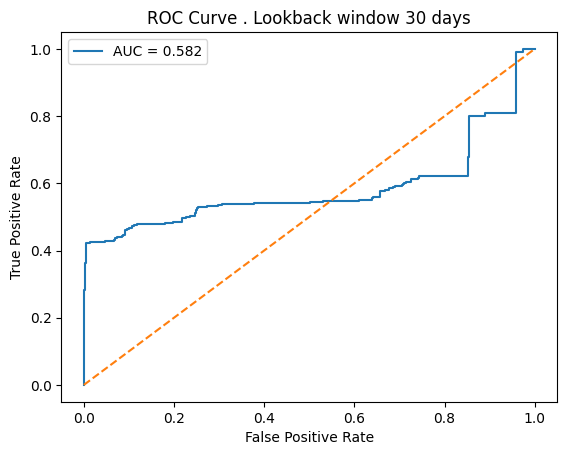

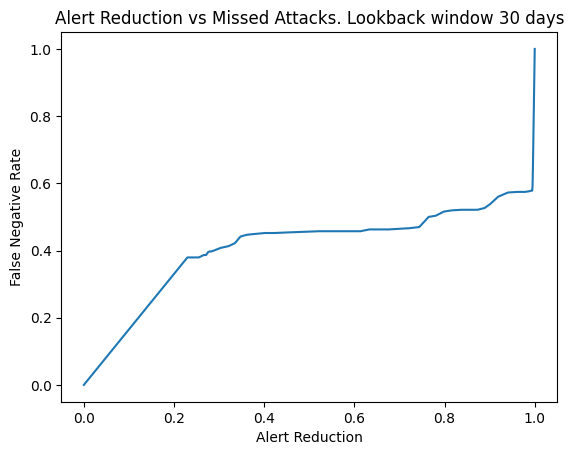

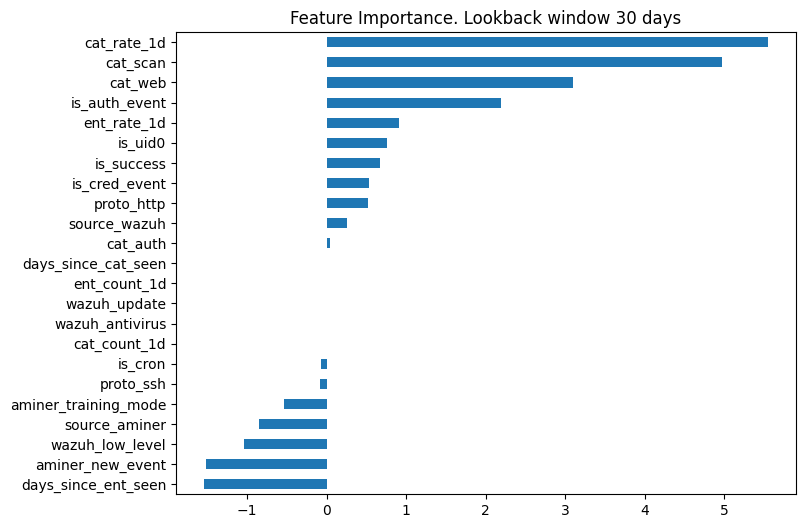

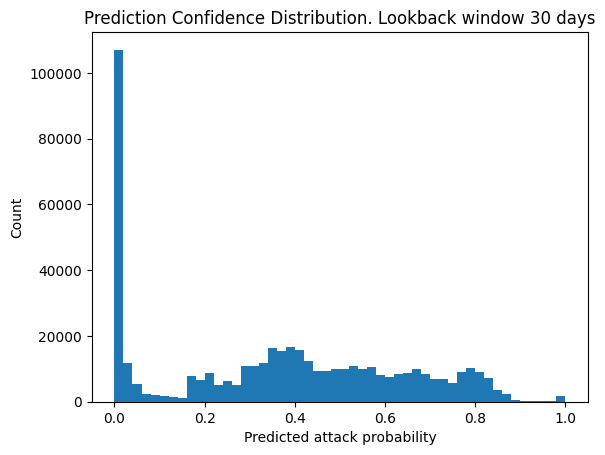

In [94]:
lookback_window = [1, 7, 30]
df = pd.read_csv("../data/ait_ads/combined_ait_labeled.csv")

for i in range(0,len(lookback_window)):
    window_size = pd.Timedelta(days=lookback_window[i])

    X_dyn, y, df_used = build_dyn_features(df, window_size)
    X_static = build_static_features(df_used)

    X = pd.concat([X_dyn, X_static], axis=1).reset_index(drop=True)
    y = np.asarray(y)

    print(X.shape)
    print(y.shape)

    assert len(X) == len(y)

    results = train_and_evaluate(X, y, 3)
    plot_all(X, results, lookback_window[i])
    